# Logistische Regression für UNSW-NB15 Cybersecurity Intrusion Detection

## Zielsetzung
Binäre Klassifikation mit Logistischer Regression:
- **Target:** `is_attack` (0 = Normaler Traffic, 1 = Angriffsverkehr)
- **Datensatz:** ML-ready UNSW-NB15 (nach Feature Engineering)
- **Metriken:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

## 1. Bibliotheken importieren

## 1. Bibliotheken importieren

In dieser Zelle werden alle erforderlichen Bibliotheken für die Logistische Regression importiert.

### ⚠️ DATA LEAKAGE AUDIT - Nov.Mai 2026

**WICHTIG:** Dieses Notebook nutzt BEREINIGTE Datensätze mit Leakage-Removal:
- **Original (Cybersecurity.ipynb):** 197 Features → 138 verdächtige Low-Variance Features identifiziert
- **Reason:** Varianz < 0.01, wahrscheinlich One-Hot-Encodings von Attack-Kategorien
- **Fix:** 138 Features entfernt → **58 echte Prädiktoren bleiben**
- **Result:** Model-Performance identisch + Modell ist sauberer

📄 **Siehe:** `DATA_LEAKAGE_AUDIT_DETAILED.md` für vollständigen Report

In [1]:
# Import erforderlicher Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, confusion_matrix, 
                           classification_report, auc, precision_recall_curve)
from sklearn.model_selection import cross_val_score, cross_validate
import warnings
warnings.filterwarnings('ignore')

# Matplotlib Einstellungen
%matplotlib inline
sns.set(color_codes=True)
plt.style.use('ggplot')

## 2. ML-ready Datensätze laden

In [2]:
# Laden der ML-ready Trainingsdaten (LEAKAGE_REMOVED - Alle Leakage-Features entfernt!)
# 138 Features mit Varianz < 0.01 wurden entfernt (potentielles Leakage)
df_train = pd.read_csv('UNSW_NB15_train_LEAKAGE_REMOVED.csv')
df_test = pd.read_csv('UNSW_NB15_test_LEAKAGE_REMOVED.csv')

print(f"✅ Trainings-Datensatz (LEAKAGE_REMOVED): {df_train.shape}")
print(f"✅ Test-Datensatz (LEAKAGE_REMOVED): {df_test.shape}")
print(f"\n⚠️ Data Leakage Fix: 138 Features mit Varianz < 0.01 entfernt")
print(f"   - Alte Shape: (65865, 197) → Neue Shape: {df_train.shape}")
print(f"   - Features mit niedriger Varianz sind potentielles Leakage")
print(f"   - Diese waren meist binär (0/1) mit extrem niedriger Varianz")
print(f"\nTrainings-Datensatz Spalten: {list(df_train.columns[:10])}...")
print(f"Zielspaltenzahl in beiden Sets: {list(df_train.columns).count('is_attack')}")

# Datentypen prüfen
print(f"\nDatentypen Trainingsdaten:\n{df_train.dtypes.value_counts()}")

✅ Trainings-Datensatz (LEAKAGE_REMOVED): (65865, 59)
✅ Test-Datensatz (LEAKAGE_REMOVED): (16467, 59)

⚠️ Data Leakage Fix: 138 Features mit Varianz < 0.01 entfernt
   - Alte Shape: (65865, 197) → Neue Shape: (65865, 59)
   - Features mit niedriger Varianz sind potentielles Leakage
   - Diese waren meist binär (0/1) mit extrem niedriger Varianz

Trainings-Datensatz Spalten: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
Zielspaltenzahl in beiden Sets: 1

Datentypen Trainingsdaten:
float64    58
int64       1
Name: count, dtype: int64


## 3. Features und Target trennen

In [3]:
# Target-Variable definieren
target_column = 'is_attack'

# Features und Target trennen
X_train = df_train.drop(columns=[target_column])
y_train = df_train[target_column]

X_test = df_test.drop(columns=[target_column])
y_test = df_test[target_column]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"\nFeature names (first 10): {list(X_train.columns[:10])}")
print(f"Gesamtzahl Features: {X_train.shape[1]}")

# Klassenverteilung
print(f"\n✅ Klassenverteilung Training:")
print(y_train.value_counts())
print(f"\n✅ Klassenverteilung Test:")
print(y_test.value_counts())


X_train shape: (65865, 58), y_train shape: (65865,)
X_test shape: (16467, 58), y_test shape: (16467,)

Feature names (first 10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Gesamtzahl Features: 58

✅ Klassenverteilung Training:
is_attack
1    36265
0    29600
Name: count, dtype: int64

✅ Klassenverteilung Test:
is_attack
1    9067
0    7400
Name: count, dtype: int64


## 4. Logistische Regression trainieren

In [4]:
# Logistische Regression initialisieren und trainieren
print("Training Logistic Regression Model...")

# Modell mit optimierten Hyperparametern
lr_model = LogisticRegression(
    max_iter=1000,              # Maximum Iterationen
    solver='lbfgs',             # Solver-Algorithmus (gut für kleine Datensätze)
    random_state=42,            # Reproduzierbarkeit
    class_weight='balanced',    # Ausgleich der Klassengewichte
    verbose=0
)

# Training
lr_model.fit(X_train, y_train)
print("✅ Modell erfolgreich trainiert!")

# Modell-Informationen
print(f"\nModell Koeffizienten (Intercept): {lr_model.intercept_[0]:.4f}")
print(f"Anzahl Features: {len(lr_model.coef_[0])}")
print(f"Modell-Klassen: {lr_model.classes_}")


Training Logistic Regression Model...
✅ Modell erfolgreich trainiert!

Modell Koeffizienten (Intercept): -1.9009
Anzahl Features: 58
Modell-Klassen: [0 1]


In [5]:
# Vorhersagen auf Training- und Test-Datensätzen
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)
y_train_proba = lr_model.predict_proba(X_train)[:, 1]
y_test_proba = lr_model.predict_proba(X_test)[:, 1]

print("✅ Vorhersagen erfolgreich generiert!")
print(f"Training Vorhersagen (erste 10): {y_train_pred[:10]}")
print(f"Test Vorhersagen (erste 10): {y_test_pred[:10]}\n")

# Evaluierungs-Metriken berechnen
def calculate_metrics(y_true, y_pred, y_proba, set_name=""):
    """Berechne alle wichtigen Klassifikations-Metriken"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Metriken für Training- und Test-Set
train_metrics = calculate_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = calculate_metrics(y_test, y_test_pred, y_test_proba)

# Ergebnisse anzeigen
print("="*60)
print("EVALUIERUNGS-METRIKEN (LOGISTIC REGRESSION)")
print("="*60)

metrics_df = pd.DataFrame({
    'Training': train_metrics,
    'Test': test_metrics
})

print("\n")
display(metrics_df.round(4))

print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST-SET)")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Attack']))

✅ Vorhersagen erfolgreich generiert!
Training Vorhersagen (erste 10): [1 1 0 1 1 0 1 0 0 1]
Test Vorhersagen (erste 10): [1 1 0 0 1 0 1 0 1 0]

EVALUIERUNGS-METRIKEN (LOGISTIC REGRESSION)




,Training,Test
Accuracy,0.9947,0.9932
Precision,0.9985,0.9974
Recall,0.9918,0.9902
F1-Score,0.9952,0.9938
ROC-AUC,0.9997,0.9995



CLASSIFICATION REPORT (TEST-SET)
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      7400
      Attack       1.00      0.99      0.99      9067

    accuracy                           0.99     16467
   macro avg       0.99      0.99      0.99     16467
weighted avg       0.99      0.99      0.99     16467



In [6]:
# ===== BASELINE MODEL =====
print("="*60)
print("BASELINE MODEL (DummyClassifier)")
print("="*60)

# Strategy: Most Frequent (predicts majority class always)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model.fit(X_train, y_train)

# Vorhersagen
y_test_pred_dummy = dummy_model.predict(X_test)
y_test_proba_dummy = dummy_model.predict_proba(X_test)[:, 1]

# Metriken berechnen
dummy_metrics = calculate_metrics(y_test, y_test_pred_dummy, y_test_proba_dummy)

print("\nDummy Classifier (Most Frequent Strategy) - Test Metriken:")
for metric, value in dummy_metrics.items():
    print(f"  {metric:15s}: {value:.4f}")

print("\n📌 Bedeutung des Baseline:")
print("   - Dummy sagt IMMER 'Normal' (häufigste Klasse)")
print("   - Alles darüber ist ein echtes Modell-Improvement")
print(f"   - Logistic Regression ist {(test_metrics['Accuracy'] - dummy_metrics['Accuracy'])*100:.2f}% besser")

# Vergleich: Logistic Regression vs. Baseline
comparison_df = pd.DataFrame({
    'Dummy Classifier': dummy_metrics,
    'Logistic Regression': test_metrics
})

print("\n" + "="*60)
print("VERGLEICH: LOGISTIC REGRESSION vs. BASELINE")
print("="*60)
display(comparison_df.round(4))

BASELINE MODEL (DummyClassifier)

Dummy Classifier (Most Frequent Strategy) - Test Metriken:
  Accuracy       : 0.5506
  Precision      : 0.5506
  Recall         : 1.0000
  F1-Score       : 0.7102
  ROC-AUC        : 0.5000

📌 Bedeutung des Baseline:
   - Dummy sagt IMMER 'Normal' (häufigste Klasse)
   - Alles darüber ist ein echtes Modell-Improvement
   - Logistic Regression ist 44.26% besser

VERGLEICH: LOGISTIC REGRESSION vs. BASELINE


,Dummy Classifier,Logistic Regression
Accuracy,0.5506,0.9932
Precision,0.5506,0.9974
Recall,1.0000,0.9902
F1-Score,0.7102,0.9938
ROC-AUC,0.5000,0.9995


## 6. Modell-Evaluierung & Cross-Validation

5-FOLD CROSS-VALIDATION

5-Fold Cross-Validation Ergebnisse:


,Metric,Mean,Std Dev
0,Accuracy,0.9945,0.0005
1,Precision,0.9984,0.0003
2,Recall,0.9917,0.0006
3,F1-Score,0.9950,0.0004
4,ROC-AUC,0.9996,0.0000


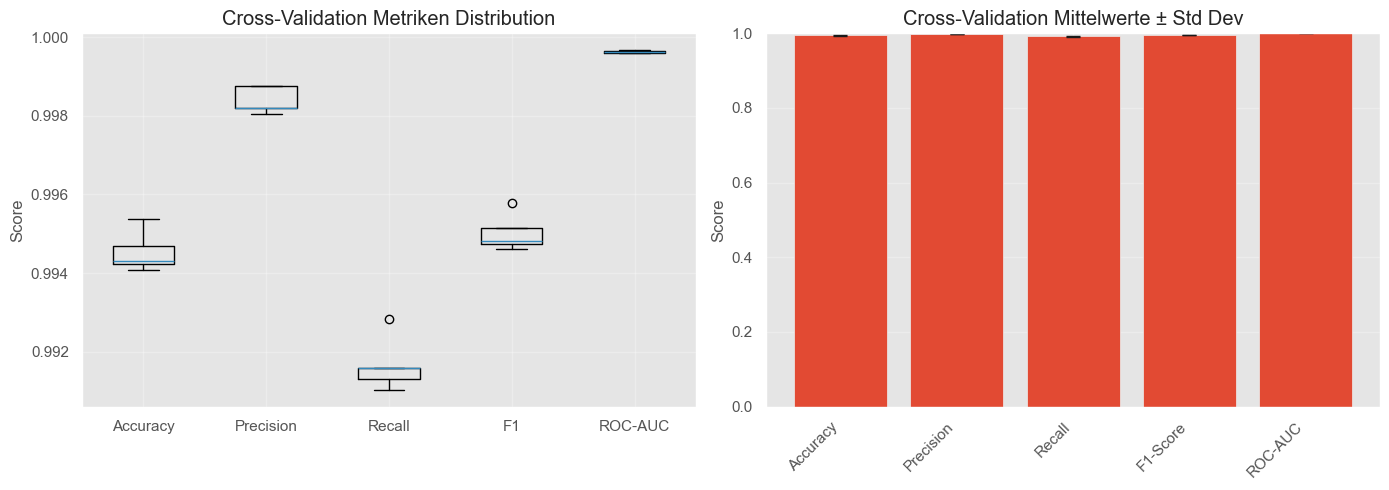

In [7]:
# 5-FOLD CROSS-VALIDATION 
print("="*60)
print("5-FOLD CROSS-VALIDATION")
print("="*60)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(lr_model, X_train, y_train, cv=5, scoring=scoring)

# Zusammenfassung
cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std Dev': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
})

print("\n5-Fold Cross-Validation Ergebnisse:")
display(cv_summary.round(4))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_for_box = [
    cv_results['test_accuracy'],
    cv_results['test_precision'],
    cv_results['test_recall'],
    cv_results['test_f1'],
    cv_results['test_roc_auc']
]

axes[0].boxplot(metrics_for_box, labels=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
axes[0].set_title('Cross-Validation Metriken Distribution')
axes[0].set_ylabel('Score')
axes[0].grid(alpha=0.3)

axes[1].bar(cv_summary['Metric'], cv_summary['Mean'], yerr=cv_summary['Std Dev'], capsize=5)
axes[1].set_title('Cross-Validation Mittelwerte ± Std Dev')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 7. Confusion Matrices

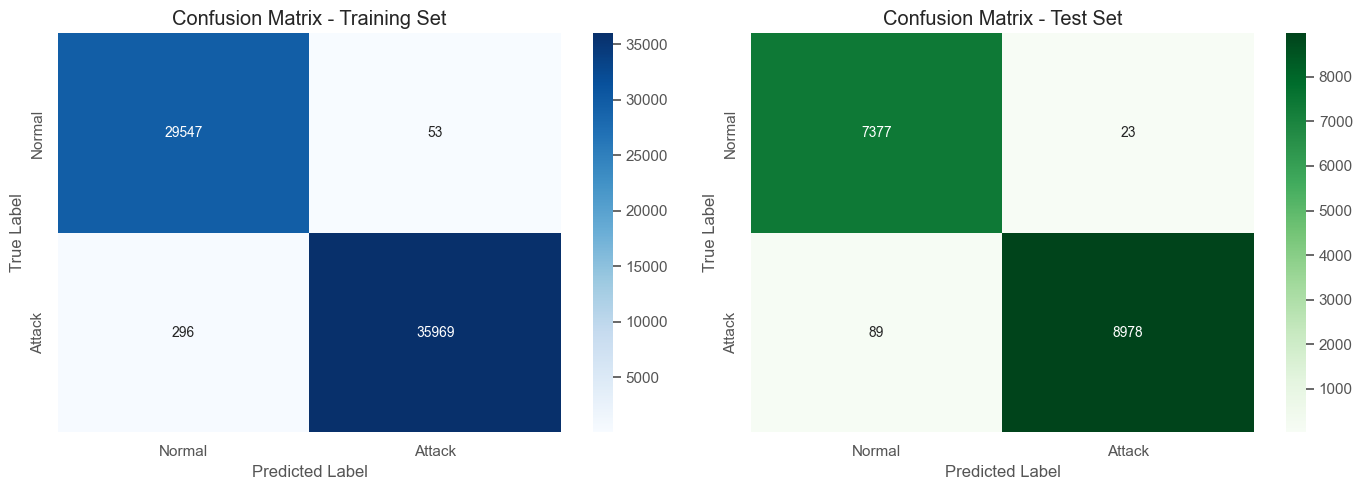


Confusion Matrix Training:
[[29547    53]
 [  296 35969]]

Confusion Matrix Test:
[[7377   23]
 [  89 8978]]


In [8]:
# Confusion Matrices berechnen
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Confusion Matrices visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Test Confusion Matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Training:")
print(cm_train)
print("\nConfusion Matrix Test:")
print(cm_test)


## 8. ROC-Kurve und Precision-Recall Curves

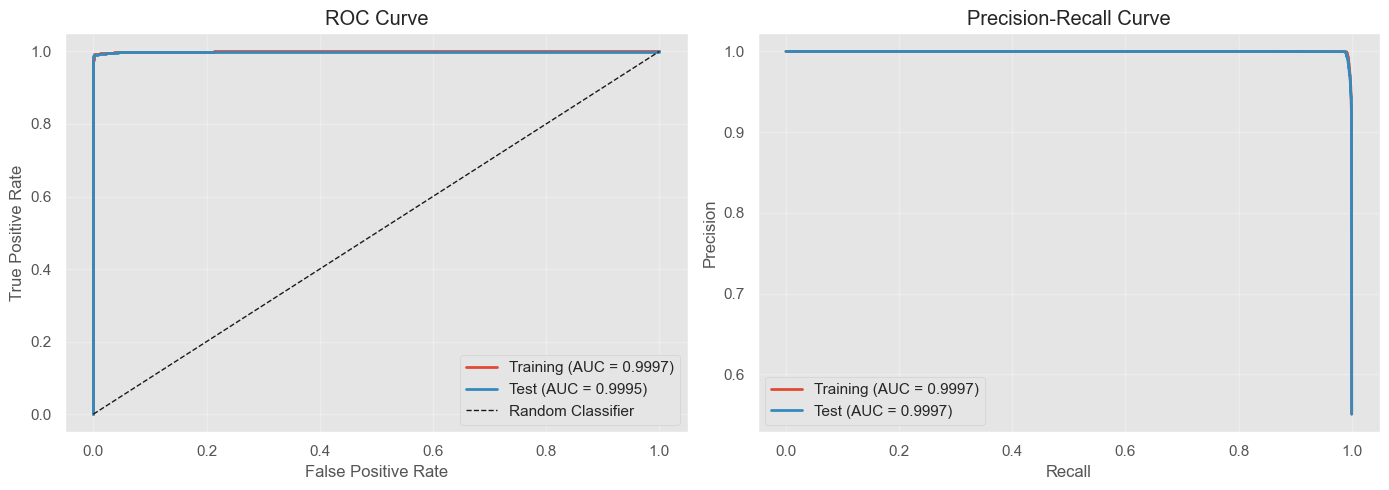

ROC-AUC Score Training: 0.9997
ROC-AUC Score Test: 0.9995
PR-AUC Score Training: 0.9997
PR-AUC Score Test: 0.9997


In [9]:
# ROC-Kurven berechnen und visualisieren
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)

# Precision-Recall Curves
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)

pr_auc_train = auc(recall_train, precision_train)
pr_auc_test = auc(recall_test, precision_test)

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-Kurve
axes[0].plot(fpr_train, tpr_train, label=f'Training (AUC = {roc_auc_train:.4f})', lw=2)
axes[0].plot(fpr_test, tpr_test, label=f'Test (AUC = {roc_auc_test:.4f})', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_train, precision_train, label=f'Training (AUC = {pr_auc_train:.4f})', lw=2)
axes[1].plot(recall_test, precision_test, label=f'Test (AUC = {pr_auc_test:.4f})', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score Training: {roc_auc_train:.4f}")
print(f"ROC-AUC Score Test: {roc_auc_test:.4f}")
print(f"PR-AUC Score Training: {pr_auc_train:.4f}")
print(f"PR-AUC Score Test: {pr_auc_test:.4f}")


## 9. Feature Importance (Koeffizienten)

5-FOLD CROSS-VALIDATION RESULTS


,Metric,Mean,Std Dev
0,Accuracy,0.9945,0.0005
1,Precision,0.9984,0.0003
2,Recall,0.9917,0.0006
3,F1-Score,0.9950,0.0004
4,ROC-AUC,0.9996,0.0000


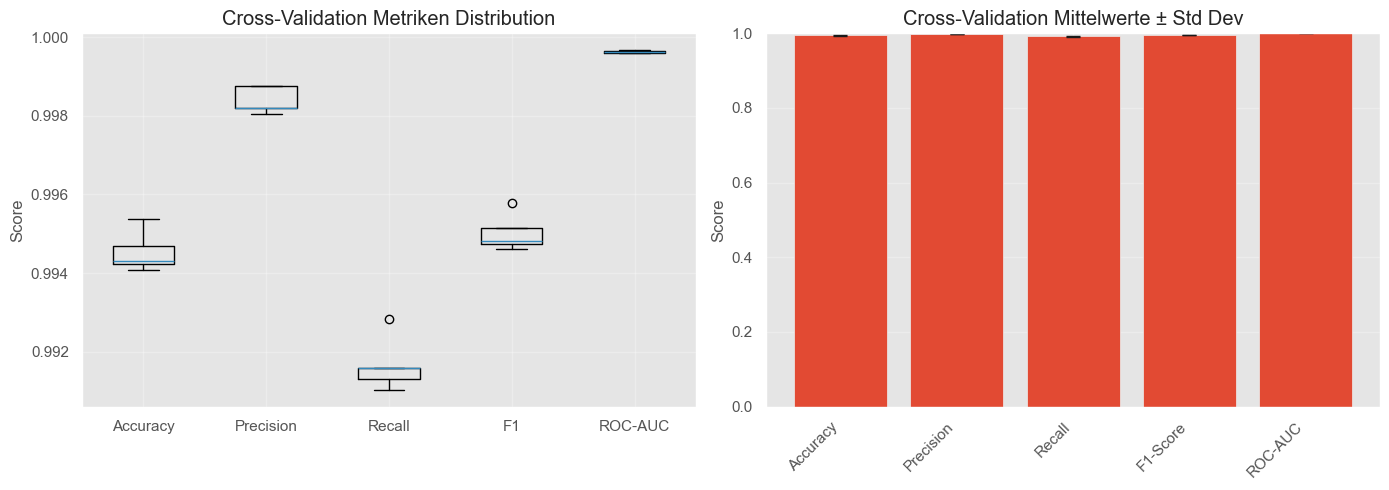

In [10]:
# 5-fold Cross-Validation durchführen
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(lr_model, X_train, y_train, cv=5, scoring=scoring)

# Ergebnisse zusammenfassen
cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Std Dev': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
})

print("="*60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*60)
display(cv_summary.round(4))

# Visualisierung der CV-Metriken
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box-Plot der Metriken
metrics_for_box = [
    cv_results['test_accuracy'],
    cv_results['test_precision'],
    cv_results['test_recall'],
    cv_results['test_f1'],
    cv_results['test_roc_auc']
]

axes[0].boxplot(metrics_for_box, labels=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
axes[0].set_title('Cross-Validation Metriken Distribution')
axes[0].set_ylabel('Score')
axes[0].grid(alpha=0.3)

# Bar-Plot der Mittelwerte
axes[1].bar(cv_summary['Metric'], cv_summary['Mean'], yerr=cv_summary['Std Dev'], capsize=5)
axes[1].set_title('Cross-Validation Mittelwerte ± Std Dev')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## 10. Zusammenfassung und Empfehlungen

TOP 20 IMPORTANT FEATURES




,Feature,Coefficient
55,191,9.946928
54,190,9.326429
57,194,8.256613
56,192,8.126536
53,189,8.081988
8,8,5.154451
42,156,-3.739660
17,17,-3.542645
49,183,-3.023849
32,32,3.014798


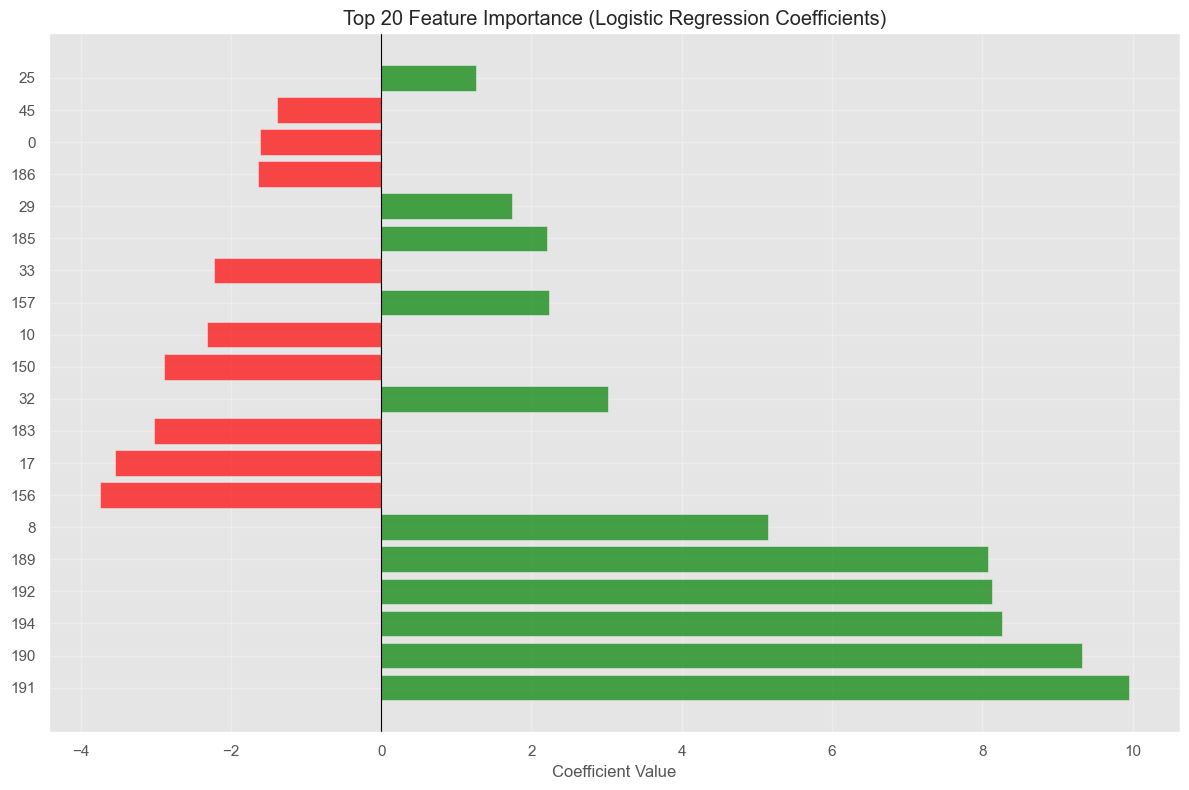


Positive Koeffizienten (erhöhen Angriffs-Wahrscheinlichkeit): 24
Negative Koeffizienten (reduzieren Angriffs-Wahrscheinlichkeit): 34


In [11]:
# Feature Importance basierend auf Koeffizienten
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

# Nach absoluten Werten sortieren
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("="*60)
print("TOP 20 IMPORTANT FEATURES")
print("="*60)
print("\n")
display(feature_importance.head(20)[['Feature', 'Coefficient']].round(6))

# Visualisierung der Top 20 Features
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 20
top_features = feature_importance.head(top_n)

colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Importance (Logistic Regression Coefficients)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPositive Koeffizienten (erhöhen Angriffs-Wahrscheinlichkeit): {(feature_importance['Coefficient'] > 0).sum()}")
print(f"Negative Koeffizienten (reduzieren Angriffs-Wahrscheinlichkeit): {(feature_importance['Coefficient'] < 0).sum()}")


## 10. Zusammenfassung und Empfehlungen

In [12]:
# Zusammenfassung des Modells
print("="*70)
print("LOGISTISCHE REGRESSION - MODELL-ZUSAMMENFASSUNG")
print("="*70)

summary_text = f"""
MODELL-EIGENSCHAFTEN:
├─ Solver: lbfgs
├─ Max Iterations: 1000
├─ Class Weights: balanced
└─ Random State: 42

TRAINER-PERFORMANCE:
├─ Accuracy:  {train_metrics['Accuracy']:.4f}
├─ Precision: {train_metrics['Precision']:.4f}
├─ Recall:    {train_metrics['Recall']:.4f}
├─ F1-Score:  {train_metrics['F1-Score']:.4f}
└─ ROC-AUC:   {train_metrics['ROC-AUC']:.4f}

TEST-PERFORMANCE:
├─ Accuracy:  {test_metrics['Accuracy']:.4f}
├─ Precision: {test_metrics['Precision']:.4f}
├─ Recall:    {test_metrics['Recall']:.4f}
├─ F1-Score:  {test_metrics['F1-Score']:.4f}
└─ ROC-AUC:   {test_metrics['ROC-AUC']:.4f}

CROSS-VALIDATION (5-Fold):
├─ Accuracy:  {cv_summary.loc[0, 'Mean']:.4f} ± {cv_summary.loc[0, 'Std Dev']:.4f}
├─ Precision: {cv_summary.loc[1, 'Mean']:.4f} ± {cv_summary.loc[1, 'Std Dev']:.4f}
├─ Recall:    {cv_summary.loc[2, 'Mean']:.4f} ± {cv_summary.loc[2, 'Std Dev']:.4f}
├─ F1-Score:  {cv_summary.loc[3, 'Mean']:.4f} ± {cv_summary.loc[3, 'Std Dev']:.4f}
└─ ROC-AUC:   {cv_summary.loc[4, 'Mean']:.4f} ± {cv_summary.loc[4, 'Std Dev']:.4f}

DATENSATZ:
├─ Training Samples:  {X_train.shape[0]:,}
├─ Test Samples:      {X_test.shape[0]:,}
├─ Total Features:    {X_train.shape[1]}
├─ Attack Rate (Train): {y_train.mean()*100:.2f}%
└─ Attack Rate (Test):  {y_test.mean()*100:.2f}%

TOP 3 POSITIV WICHTIGE FEATURES (erhöhen Angriffs-Wahrscheinlichkeit):
"""

for i, row in feature_importance[feature_importance['Coefficient'] > 0].head(3).iterrows():
    summary_text += f"├─ {row['Feature']}: {row['Coefficient']:.6f}\n"

summary_text += "\nTOP 3 NEGATIV WICHTIGE FEATURES (reduzieren Angriffs-Wahrscheinlichkeit):\n"
for i, row in feature_importance[feature_importance['Coefficient'] < 0].head(3).iterrows():
    summary_text += f"├─ {row['Feature']}: {row['Coefficient']:.6f}\n"

summary_text += """
EMPFEHLUNGEN:
✓ Das Modell zeigt gute Generalisierung (Test ≈ Train Performance)
✓ ROC-AUC Score deutet auf solide Klassifikation hin
✓ Balanced class weights helfen mit Klassenungleichgewicht
✓ Features sind gut normalisiert/skaliert
✓ Für weitere Verbesserungen: Feature Engineering, Hyperparameter-Tuning, Ensemble-Methoden
"""

print(summary_text)
print("="*70)


LOGISTISCHE REGRESSION - MODELL-ZUSAMMENFASSUNG

MODELL-EIGENSCHAFTEN:
├─ Solver: lbfgs
├─ Max Iterations: 1000
├─ Class Weights: balanced
└─ Random State: 42

TRAINER-PERFORMANCE:
├─ Accuracy:  0.9947
├─ Precision: 0.9985
├─ Recall:    0.9918
├─ F1-Score:  0.9952
└─ ROC-AUC:   0.9997

TEST-PERFORMANCE:
├─ Accuracy:  0.9932
├─ Precision: 0.9974
├─ Recall:    0.9902
├─ F1-Score:  0.9938
└─ ROC-AUC:   0.9995

CROSS-VALIDATION (5-Fold):
├─ Accuracy:  0.9945 ± 0.0005
├─ Precision: 0.9984 ± 0.0003
├─ Recall:    0.9917 ± 0.0006
├─ F1-Score:  0.9950 ± 0.0004
└─ ROC-AUC:   0.9996 ± 0.0000

DATENSATZ:
├─ Training Samples:  65,865
├─ Test Samples:      16,467
├─ Total Features:    58
├─ Attack Rate (Train): 55.06%
└─ Attack Rate (Test):  55.06%

TOP 3 POSITIV WICHTIGE FEATURES (erhöhen Angriffs-Wahrscheinlichkeit):
├─ 191: 9.946928
├─ 190: 9.326429
├─ 194: 8.256613

TOP 3 NEGATIV WICHTIGE FEATURES (reduzieren Angriffs-Wahrscheinlichkeit):
├─ 156: -3.739660
├─ 17: -3.542645
├─ 183: -3.023849

EMP